In [1]:
import requests
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt

## Generation trends NITI

In [2]:
url = 'https://icedapi.niti.gov.in/v1/gen-metatable-data'

headers = {
    "accept": "application/json, text/plain, */*",
    "accept-language": "en-GB,en;q=0.9",
    "content-type": "application/json",
    "origin": "https://iced.niti.gov.in",
    "priority": "u=1, i",
    "referer": "https://iced.niti.gov.in/",
    "user-agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/153.0.0.0 Safari/537.36"
}

payload = {
    "source": "solar",
    "rangeType": "monthly"
}


response = requests.post(
    url=url, 
    headers=headers, 
    json=payload
)

print(f'Status code: {response.status_code}')

data = response.json()

if isinstance(data, list):
    df = pd.DataFrame(data)


Status code: 200


In [3]:

df.to_csv('../data/raw/niti_aayog/solar-gen-trends-15to26.csv', index=False)

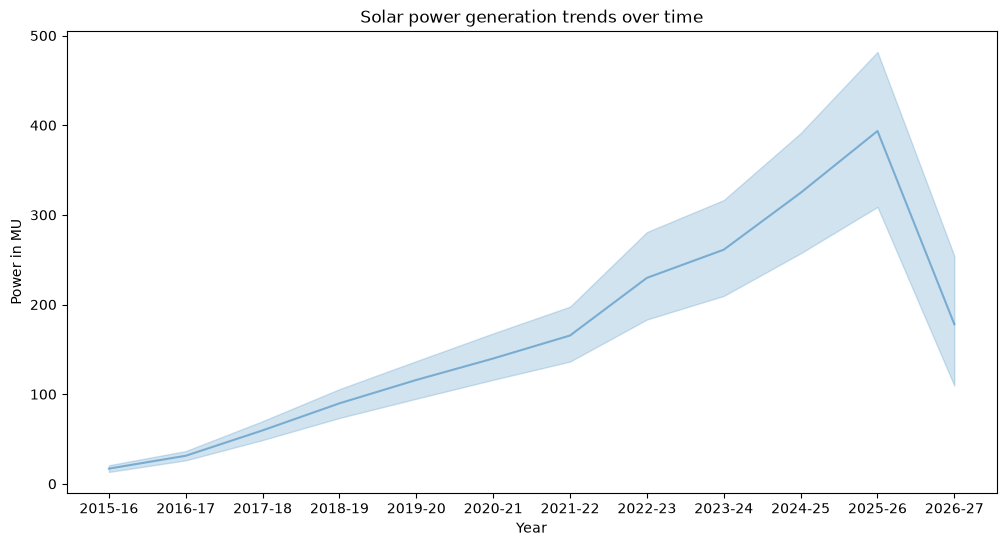

In [4]:
plt.figure(figsize=(12,6))
sns.lineplot(x=df['year'], y=df['generation'], alpha=0.5)
plt.title('Solar power generation trends over time')
plt.xlabel('Year')
plt.ylabel('Power in MU')
plt.show()

# Installed Capacity Trends NITI

In [5]:
url = "https://icedapi.niti.gov.in/v1/capacity-metatable-data?switchMetaData=false"

headers = {
    "accept" : "application/json, text/plain, */*",
    "accept-language": "en-GB, en; q=0.9",
    "dnt": "1", 
    "origin": "https://iced.niti.gov.in", 
    "referer": "https://iced.niti.gov.in/", 
    "user-agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/153.0.0.0 Safari/537.36"
}

response = requests.get(url=url, headers=headers)

print(response.status_code)

data = response.json()

if isinstance(data, list):
    df = pd.DataFrame(data)



200


In [6]:
df = df[df['source'].str.strip() =='solar']
df.to_csv('../data/raw/niti_aayog/solar-installed-capacity-trends-15to26.csv', index=False)

In [7]:
print(df.describe())
print(df.info())

           capacity
count    438.000000
mean    1760.925822
std     4769.506362
min        0.120000
25%       13.585000
50%       95.600000
75%     1159.900000
max    44135.330000
<class 'pandas.DataFrame'>
Index: 438 entries, 1 to 2037
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   state     438 non-null    str    
 1   fyear     438 non-null    str    
 2   source    438 non-null    str    
 3   capacity  438 non-null    float64
dtypes: float64(1), str(3)
memory usage: 26.9 KB
None


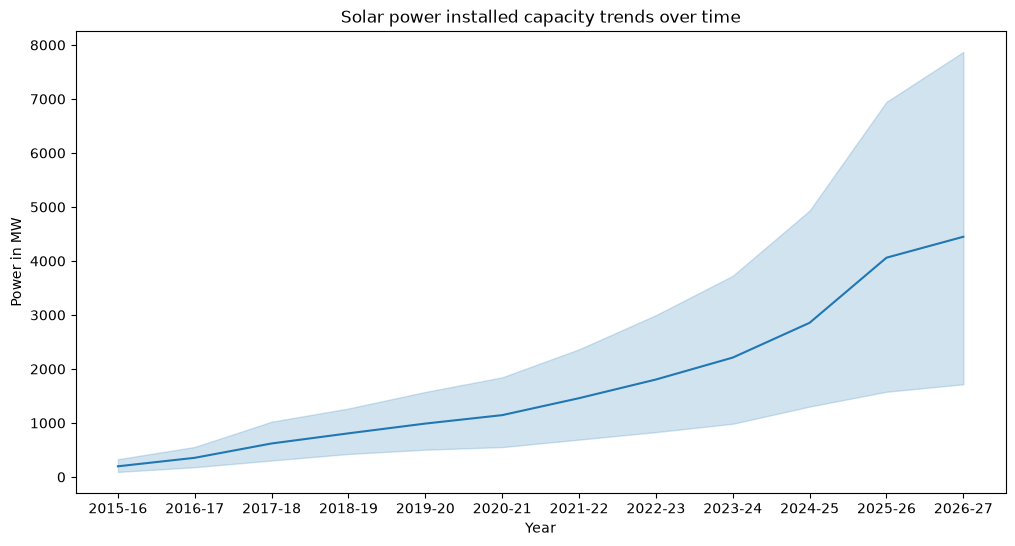

In [8]:
plt.figure(figsize=(12,6))
sns.lineplot(x=df.fyear, y=df.capacity)
plt.title('Solar power installed capacity trends over time')
plt.xlabel('Year')
plt.ylabel('Power in MW')
plt.show()